In [1]:
import pandas as pd

df = pd.read_parquet('../data/raw/yellow_tripdata_2025-06.parquet')

In [2]:
df.shape

(4322960, 20)

In [3]:
df.sample(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
3042418,1,2025-06-30 10:52:09,2025-06-30 11:17:25,1.0,2.20,99.0,N,244,41,1,19.50,0.0,0.5,0.00,0.0,0.0,20.00,0.0,0.0,0.00
922142,2,2025-06-09 19:01:24,2025-06-09 19:05:02,1.0,0.70,1.0,N,113,144,1,5.80,2.5,0.5,3.26,0.0,1.0,16.31,2.5,0.0,0.75
4026210,2,2025-06-23 13:19:13,2025-06-23 13:26:43,NaN,0.83,NaN,None,37,17,0,9.61,0.0,0.5,0.00,0.0,1.0,11.11,NaN,NaN,0.00


In [4]:
df.isna().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1212946
trip_distance                  0
RatecodeID               1212946
store_and_fwd_flag       1212946
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1212946
Airport_fee              1212946
cbd_congestion_fee             0
dtype: int64

In [5]:
# ЧАСТЬ 1: ПРОПУСКИ И ДУБЛИКАТЫ
# строки с хотя бы одним NaN — это ровно те же строки, где payment_type == 0

df.index[df.isna().any(axis=1)].equals(df.index[df["payment_type"] == 0])

True

In [6]:
df[df.duplicated()].shape

(0, 20)

In [7]:
# ЧАСТЬ 2: МИНИМАЛЬНАЯ ОЧИСТКА ДАННЫХ
mask_1 = df["tpep_pickup_datetime"] > df["tpep_dropoff_datetime"]
mask_2 = (df["tpep_pickup_datetime"] == df["tpep_dropoff_datetime"]) & (df['trip_distance'] != 0)
mask_3 = (df["tpep_pickup_datetime"] < '2025-06-01') | (df["tpep_pickup_datetime"] >= '2025-07-01')
df[mask_1 | mask_2 | mask_3]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
4,7,2025-06-01 00:16:32,2025-06-01 00:16:32,1.0,2.22,1.0,N,48,234,1,20.50,0.0,0.5,5.25,0.00,1.0,31.50,2.5,0.0,0.75
25,7,2025-06-01 00:07:41,2025-06-01 00:07:41,2.0,2.21,1.0,N,186,79,1,17.00,0.0,0.5,1.50,0.00,1.0,24.25,2.5,0.0,0.75
26,7,2025-06-01 00:16:41,2025-06-01 00:16:41,1.0,0.56,1.0,N,79,114,1,5.10,0.0,0.5,2.17,0.00,1.0,13.02,2.5,0.0,0.75
27,7,2025-06-01 00:32:06,2025-06-01 00:32:06,2.0,2.01,1.0,N,114,186,1,14.20,0.0,0.5,0.00,0.00,1.0,19.95,2.5,0.0,0.75
48,7,2025-06-01 00:00:09,2025-06-01 00:00:09,1.0,2.84,1.0,N,158,162,1,21.20,0.0,0.5,5.39,0.00,1.0,32.34,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4127470,2,2025-06-25 20:29:00,2025-06-25 20:29:00,NaN,0.07,NaN,None,236,236,0,18.58,0.0,0.5,0.00,0.00,1.0,22.58,NaN,NaN,0.00
4171019,2,2025-06-26 22:44:46,2025-06-26 22:44:46,NaN,3.97,NaN,None,90,90,0,24.92,0.0,0.5,0.00,0.00,1.0,29.67,NaN,NaN,0.75
4171573,2,2025-06-26 22:04:00,2025-06-26 22:04:00,NaN,0.02,NaN,None,263,263,0,27.88,0.0,0.5,0.00,0.00,1.0,31.88,NaN,NaN,0.00
4176566,2,2025-06-27 00:18:45,2025-06-27 00:18:45,NaN,13.97,NaN,None,119,119,0,52.01,0.0,0.5,0.00,6.94,1.0,60.45,NaN,NaN,0.00


In [8]:
# проблемных строк 66589
# 66589 записей составляют ~1.54% от размера всей выборки, удалим эти записи
df = df[~(mask_1 | mask_2 | mask_3)]

In [9]:
# проверяю PULocationID, DOLocationID
zones = pd.read_csv("../data/raw/taxi_zone_lookup.csv")
valid_ids = set(zones["LocationID"])
print('записей с несуществующими зонами посадки:', df[~(df["PULocationID"].isin(valid_ids))].shape[0])
print('записей с несуществующими зонами высадки:', df[~(df["DOLocationID"].isin(valid_ids))].shape[0])

записей с несуществующими зонами посадки: 0
записей с несуществующими зонами высадки: 0


In [10]:
df[df["PULocationID"] == 264]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
541,1,2025-06-01 00:44:39,2025-06-01 01:00:29,1.0,3.60,1.0,N,264,264,1,18.40,4.25,0.5,0.00,0.00,1.0,24.15,2.5,0.0,0.75
2607,2,2025-06-01 00:18:11,2025-06-01 00:39:30,1.0,4.68,1.0,N,264,233,1,24.00,1.00,0.5,3.00,0.00,1.0,32.75,2.5,0.0,0.75
2696,2,2025-06-01 00:09:44,2025-06-01 00:28:00,2.0,3.50,1.0,N,264,262,1,19.10,1.00,0.5,4.97,0.00,1.0,29.82,2.5,0.0,0.75
3875,1,2025-06-01 00:33:39,2025-06-01 00:41:35,1.0,1.20,1.0,N,264,264,1,8.60,4.25,0.5,1.50,0.00,1.0,15.85,2.5,0.0,0.75
4899,2,2025-06-01 00:11:11,2025-06-01 00:24:27,2.0,2.22,1.0,N,264,186,1,14.20,1.00,0.5,1.00,0.00,1.0,20.95,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4278221,2,2025-06-29 14:52:27,2025-06-29 15:13:09,NaN,3.76,NaN,None,264,264,0,29.53,0.00,0.5,0.00,0.00,1.0,31.03,NaN,NaN,0.00
4295122,2,2025-06-29 22:59:21,2025-06-29 23:07:40,NaN,1.71,NaN,None,264,226,0,15.62,0.00,0.5,0.00,0.00,1.0,17.12,NaN,NaN,0.00
4296357,2,2025-06-29 22:15:06,2025-06-29 22:27:49,NaN,2.36,NaN,None,264,264,0,16.63,0.00,0.5,0.00,0.00,1.0,18.13,NaN,NaN,0.00
4303730,1,2025-06-30 07:44:30,2025-06-30 07:50:08,NaN,1.60,NaN,None,264,264,0,9.30,0.00,0.5,2.66,0.00,1.0,15.96,NaN,NaN,0.00


In [11]:
# записей с зоной 264 всего 6632
# Для анализа локального спроса нужна известная зона посадки, поэтому удаляю их.
df = df[df["PULocationID"] != 264]

In [13]:
# ЧАСТЬ 3: EDA
print('удалено записей из таблицы:', 4322960-df.shape[0])
print('осталось записей о поездке:', df.shape[0])
print('максимальная и минимальная даты в таблице:', df['tpep_pickup_datetime'].max(), df['tpep_pickup_datetime'].min())

удалено записей из таблицы: 73221
осталось записей о поездке: 4249739
максимальная и минимальная даты в таблице: 2025-06-30 23:59:59 2025-06-01 00:00:00


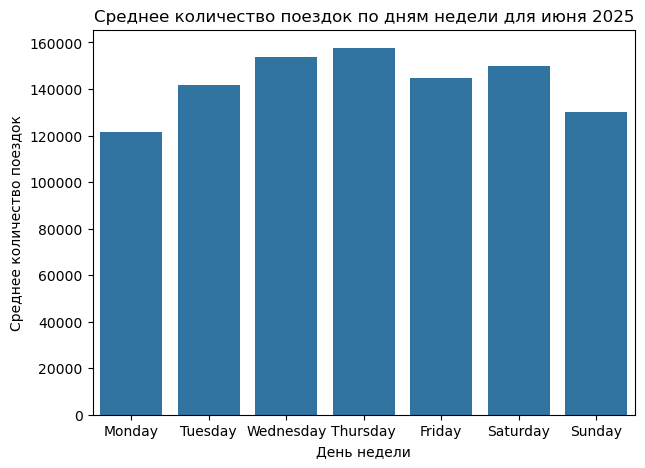

In [14]:
# рассмотрим распределение записей по дням недели (считая для начала поездки) и визуализируем
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))
first_group = df.groupby(df['tpep_pickup_datetime'].dt.date).size()
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
second_group = first_group.groupby(pd.to_datetime(first_group.index).day_name()).mean()
second_group = second_group.reindex(weekday_order)
sns.barplot(data=second_group).set(title='Среднее количество поездок по дням недели для июня 2025',
                                   xlabel='День недели',
                                   ylabel='Среднее количество поездок');

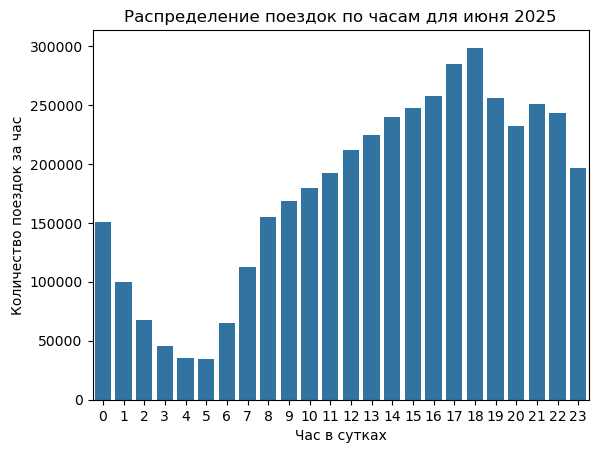

In [15]:
# рассмотрим распределение записей по часам и визуализируем
gr = df.groupby(df['tpep_pickup_datetime'].dt.hour).size()
sns.barplot(data=gr).set(
    title='Распределение поездок по часам для июня 2025', 
    xlabel='Час в сутках', 
    ylabel='Количество поездок за час');

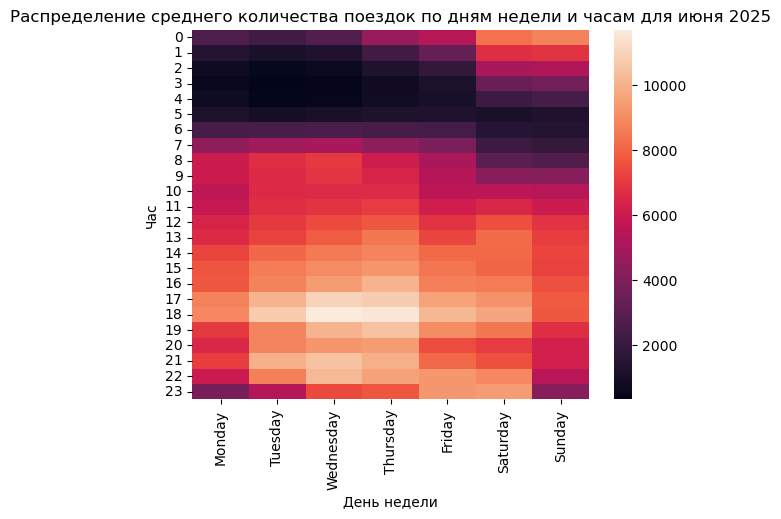

In [16]:
# Посмотрим среднее количество поездок по дню недели и часу
day_hour = df.groupby([
    df["tpep_pickup_datetime"].dt.date.rename("date"), 
    df["tpep_pickup_datetime"].dt.day_name().rename("day_of_week"), 
    df["tpep_pickup_datetime"].dt.hour.rename("hour")]).size().rename("trips")
day_hour = day_hour.reset_index()

day_hour = day_hour.groupby([
    day_hour["day_of_week"],
    day_hour["hour"]])["trips"].mean()
day_hour = day_hour.reset_index()


day_hour = day_hour.pivot(columns="day_of_week", index="hour", values="trips")
day_hour = day_hour[weekday_order]

sns.heatmap(day_hour).set(title="Распределение среднего количества поездок по дням недели и часам для июня 2025", 
                          xlabel="День недели", 
                          ylabel="Час");

In [17]:
# Графики распределений не имеют значимых отличий от майских, пик активности - среда в 18 ч,
# прошлый пик активности в четверг в 18 ч отличается совсем немного.

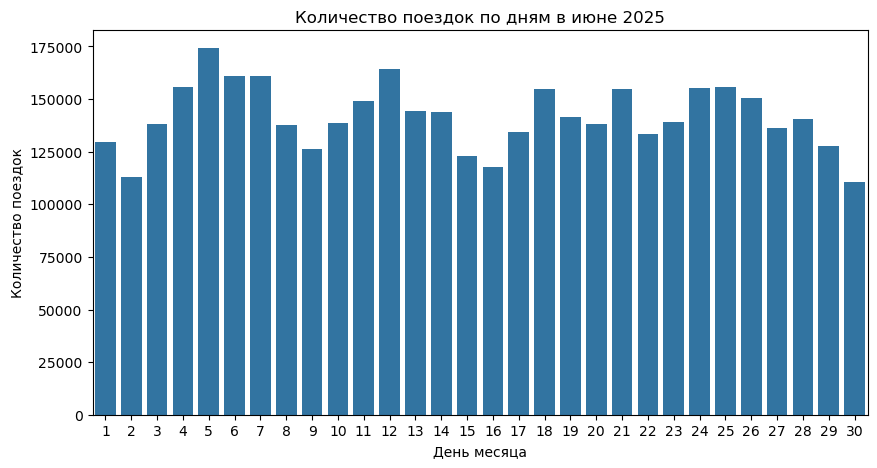

In [18]:
# Рассмотрим спрос на такси в конкретные даты

from datetime import date


gr_date = df.groupby(df["tpep_pickup_datetime"].dt.date.rename("date")).size().rename("trips")
gr_date = gr_date.to_frame()

gr_date = gr_date.reset_index()
gr_date["date"] = pd.to_datetime(gr_date["date"])
gr_date["date"] = gr_date["date"].dt.day

plt.figure(figsize=(10, 5))
sns.barplot(data=gr_date, x="date", y="trips").set(
    title="Количество поездок по дням в июне 2025", 
    xlabel="День месяца", 
    ylabel="Количество поездок");

# Паттерн прошлых месяцев сохраняется.
# Особенно низкие значения наблюдаются по понедельникам: 2, 9, 16, 23, 30 июня.

In [19]:
# Зона посадки PULocationID

start_zone_borough = df.groupby(df["PULocationID"]).size().rename("trips")
start_zone_borough = start_zone_borough.to_frame()
start_zone_borough = start_zone_borough.merge(zones[["LocationID", "Borough", "Zone"]], left_index=True, right_on='LocationID')
start_zone_borough = start_zone_borough.set_index("LocationID")
start_borough = start_zone_borough.groupby(start_zone_borough["Borough"])["trips"].sum().sort_values()
start_borough = start_borough.to_frame()
start_borough
# ожидаемо, поездки на жёлтых такси всё так же преобладают на Манхэттене

,trips
Borough,
Staten Island,479
EWR,486
Bronx,35764
Brooklyn,188199
Queens,435146
Manhattan,3587707


In [20]:
# ЧАСТЬ 4: ИСКОМЫЕ ДАННЫЕ
venue_zone_ids = [79, 161, 163, 186, 239]

df_selected = df[
    df["PULocationID"].isin(venue_zone_ids)
]

data_pickup = (
    df_selected
    .groupby([
        df_selected["tpep_pickup_datetime"].dt.floor("D").rename("date"),
        df_selected["tpep_pickup_datetime"].dt.hour.rename("hour"),
        df_selected["PULocationID"].rename("LocationID")
    ])
    .size()
    .rename("pickups")
    .reset_index()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-06-01,0,79,816
1,2025-06-01,0,161,121
2,2025-06-01,0,163,114
3,2025-06-01,0,186,180
4,2025-06-01,0,239,152
...,...,...,...,...
3594,2025-06-30,23,79,122
3595,2025-06-30,23,161,146
3596,2025-06-30,23,163,67
3597,2025-06-30,23,186,75


In [21]:
# В таблице должно быть 30 дней x 24 часа x 5 зон = 3600 записей, сейчас в таблице 3599 записей.

full_index = pd.MultiIndex.from_product(
    [
        pd.date_range("2025-06-01", "2025-06-30", freq="D"),
        range(24),
        venue_zone_ids
    ],
    names=["date", "hour", "LocationID"]
)

data_pickup = (
    data_pickup
    .set_index(["date", "hour", "LocationID"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

assert (
    data_pickup["pickups"].sum()
    ==
    df["PULocationID"].isin(venue_zone_ids).sum()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-06-01,0,79,816
1,2025-06-01,0,161,121
2,2025-06-01,0,163,114
3,2025-06-01,0,186,180
4,2025-06-01,0,239,152
...,...,...,...,...
3595,2025-06-30,23,79,122
3596,2025-06-30,23,161,146
3597,2025-06-30,23,163,67
3598,2025-06-30,23,186,75


In [22]:
# ЧАСТЬ 5: СОХРАНЕНИЕ ОБРАБОТАННЫХ ДАННЫХ

from pathlib import Path

processed_taxi_dir = Path("../data/processed/taxi")
processed_taxi_dir.mkdir(parents=True, exist_ok=True)

output_path = (
    processed_taxi_dir
    / "yellow_taxi_pickups_2025_06.parquet"
)

data_pickup.to_parquet(
    output_path,
    index=False
)

In [23]:
data_pickup_check = pd.read_parquet(output_path)

print("Размер:", data_pickup_check.shape)
print(
    "Дубликаты:",
    data_pickup_check.duplicated(
        subset=["date", "hour", "LocationID"]
    ).sum()
)
print("Пропуски:", data_pickup_check.isna().sum().sum())
print("Количество зон:", data_pickup_check["LocationID"].nunique())

assert data_pickup_check.equals(data_pickup)

Размер: (3600, 4)
Дубликаты: 0
Пропуски: 0
Количество зон: 5
